<a href="https://colab.research.google.com/github/lihkaw/BME450-project/blob/main/Resnet_BME_450_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BME 450 Final Project
Predicting Infant Emotion based on Crying Audio

In [ ]:
# Import necessary libaries
import os
import torch
import torchaudio
import torchvision.models as models
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchaudio import transforms
import matplotlib.pyplot as plt
from google.colab import drive

# Import dataset
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Transform Dataset
class AudioFolder(Dataset):
  # Initial indexing of files and labelling
    def __init__(self, root, sample_rate=16000, n_mels=64):
        self.root = root
        self.files = []
        self.classes = sorted(os.listdir(root))

        for i, cls in enumerate(self.classes):
            for filename in os.listdir(os.path.join(root, cls)):
                path = os.path.join(root, cls, filename)
                if os.path.isfile(path):
                    self.files.append((path, i))

        self.transform = nn.Sequential(
            transforms.MelSpectrogram(sample_rate=sample_rate, n_mels=n_mels),
            transforms.AmplitudeToDB()
        )

 # Find number of files
    def __len__(self):
        return len(self.files)

 # Retrieve file for dataloader
    def __getitem__(self, idx):
        path, label = self.files[idx]
        waveform, sr = torchaudio.load(path)
        if sr != 16000: # Normalize sample rate to 16000 Hz
          waveform = torchaudio.functional.resample(waveform, sr, 16000)
        waveform = waveform.mean(dim=0, keepdim=True)
        spec = self.transform(waveform)
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)
        target_len = 1024
        if spec.shape[2] < target_len:
            spec = F.pad(spec, (0, target_len - spec.shape[2]))
        else:
            spec = spec[:, :, :target_len]
        return spec, label


Train_d = AudioFolder("/content/drive/MyDrive/BME 450/Project/datasets/train")
Test_d  = AudioFolder("/content/drive/MyDrive/BME 450/Project/datasets/test")

categories  = Train_d.classes
num_classes = len(categories)

train_loader = DataLoader(Train_d, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(Test_d,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

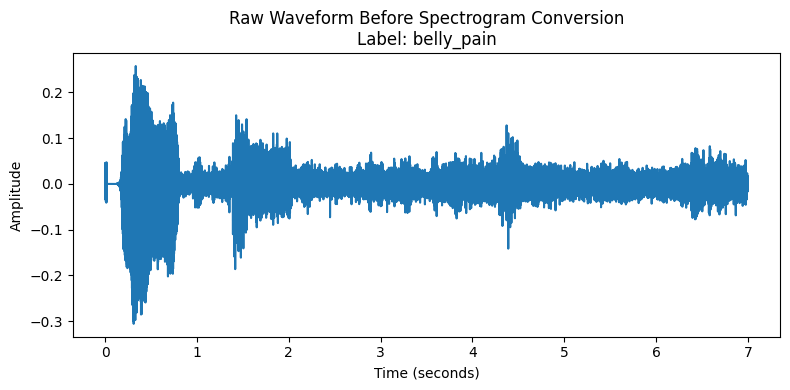

In [ ]:
import random
import torchaudio
import matplotlib.pyplot as plt

# Pick a random file from the Test_d dataset
idx = random.randint(0, len(Test_d) - 1)
path, label = Test_d.files[idx]

# Load raw audio
waveform, sr = torchaudio.load(path)

# Convert to mono for plotting
waveform = waveform.mean(0)

# Time axis for plotting
time_axis = torch.arange(0, waveform.shape[0]) / sr

# Plot
plt.figure(figsize=(8, 4))
plt.plot(time_axis, waveform.numpy())
plt.title(f"Raw Waveform Before Spectrogram Conversion\nLabel: {Test_d.classes[label]}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [ ]:
class AudioResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.input_bn = nn.BatchNorm2d(1)
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        resnet.conv1.weight = nn.Parameter(
            resnet.conv1.weight.mean(dim=1, keepdim=True)
        )
        resnet.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(resnet.fc.in_features, num_classes)
        )
        self.resnet = resnet

    def forward(self, x):
        x = self.input_bn(x)
        return self.resnet(x)

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        loss = loss_fn(model(X), y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    size, num_batches = len(dataloader.dataset), len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).sum().item()
    test_losses.append(test_loss / num_batches)
    test_accuracies.append(100 * correct / size)
    print(f"Test Error: \n Accuracy: {(100*correct/size):>0.1f}%, Avg loss: {test_loss/num_batches:>8f}\n")

# Storage
test_losses, test_accuracies = [], []

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = AudioResNet(num_classes=num_classes).to(device)
loss_fn   = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-7, weight_decay=1e-4)

for t in range(10):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(test_loader, model, loss_fn)
print("Done!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Epoch 1
-------------------------------
loss: 1.874016  [   32/  558]
loss: 1.953496  [   64/  558]
loss: 2.047386  [   96/  558]
loss: 1.902089  [  128/  558]
loss: 2.069054  [  160/  558]
loss: 1.909674  [  192/  558]
loss: 2.034412  [  224/  558]
loss: 1.874864  [  256/  558]
loss: 1.738881  [  288/  558]
loss: 1.862294  [  320/  558]
loss: 1.826101  [  352/  558]
loss: 1.988712  [  384/  558]
loss: 1.920300  [  416/  558]
loss: 2.006132  [  448/  558]
loss: 1.989249  [  480/  558]
loss: 2.107782  [  512/  558]
loss: 1.945414  [  544/  558]
loss: 1.987839  [  252/  558]
Test Error: 
 Accuracy: 19.9%, Avg loss: 1.877849

Epoch 2
-------------------------------
loss: 1.985682  [   32/  558]
loss: 1.931466  [   64/  558]
loss: 1.910405  [   96/  558]
loss: 1.979092  [  128/  558]
loss: 2.023856  [  160/  558]
loss: 2.036957  [  192/  558]
loss: 1.888485  [  224/  558]
loss: 1.920486  [  256/  558]
loss: 1.855897  [  288/  558]
loss: 2.012288  [  320/  558]
loss: 1.845225  [  352/  558]

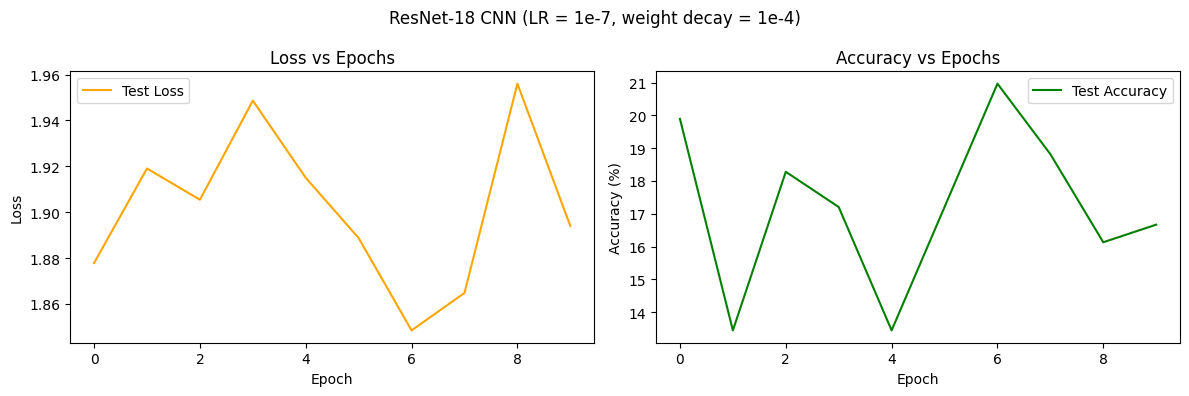

In [ ]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(test_losses, label='Test Loss', color='orange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss vs Epochs'); ax1.legend()

ax2.plot(test_accuracies, label='Test Accuracy', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy vs Epochs'); ax2.legend()

plt.suptitle('ResNet-18 CNN (LR = 1e-7, weight decay = 1e-4)')
plt.tight_layout()
plt.show()

In [ ]:
# Predict some samples
model.eval()

for idx in [0, 23, 42, 47, 500, 350, 400]:
    sample, label = Train_d[idx]
    with torch.no_grad():
        r = model(sample.unsqueeze(0).to(device))  # always 0
    print(f'Sample {idx} | Predicted: {categories[torch.argmax(r).item()]} | True label: {categories[label]}')

Sample 0 | Predicted: tired | True label: belly_pain
Sample 23 | Predicted: discomfort | True label: belly_pain
Sample 42 | Predicted: cold_hot | True label: belly_pain
Sample 47 | Predicted: tired | True label: belly_pain
Sample 500 | Predicted: tired | True label: tired
Sample 350 | Predicted: tired | True label: discomfort
Sample 400 | Predicted: tired | True label: hungry
